# 03 — Exploratory Data Analysis (EDA)

**Run order:** first cell sets **`RUN_DATA_SOURCE`** (`delta_gold` for assignment Gold table). For any Delta run: **Kernel → Restart**, then **Run All** so Delta JARs load. Figures: **`from-csv/`**, **`from-delta-lake/silver/`**, **`from-delta-lake/gold/`**.

**Spark:** this notebook uses **local** PySpark (`local[*]` on the machine running Jupyter). A stopped Docker Spark *worker* does not block it; the worker is for cluster `spark-submit`, not for this notebook.

**Scope:** basic stats, missing values, **§7 daily** + **§8 hourly** time series, categoricals, **§13** numeric distributions, **§14** summary.


In [ ]:
# --- How to run this notebook ---
# **Delta + PySpark 4:** `pip install "delta-spark>=4.0,<5"`. Set **`RUN_DATA_SOURCE`** to **`delta_gold`** (assignment) or **`delta_silver`**.  
# **Important:** After you change this cell, use **Kernel → Restart Kernel**, then **Run All from top**. If you ever ran CSV first in the same session, the JVM started without Delta JARs — only a full kernel restart fixes `Failed to find the data source: delta`.
#
# | RUN_DATA_SOURCE | Data | PNG output folder |
# |-----------------|------|-------------------|
# | `"csv"`         | `data/raw/chicago_crimes_sample.csv` | `dashboard/figures/from-csv/` |
# | `"delta_silver"`| Delta `silver/chicago_crimes_clean` | `dashboard/figures/from-delta-lake/silver/` |
# | `"delta_gold"`  | Delta `gold/chicago_crimes_features` | `dashboard/figures/from-delta-lake/gold/` |
#
# **Spark:** This notebook uses `local[*]` — PySpark runs on **your machine** (the Jupyter kernel).  
# You do **not** need the Docker Spark *worker* running for this notebook. (Workers are for `spark-submit` in containers.)
#
# **Delta tables:** Under `./delta/...` (pipeline producer + jobs 01→02→03), or set `DELTA_ROOT` in the imports cell via `os.environ` before Run All.

import os

# Assignment (Delta Gold): set to 'delta_gold', then Restart Kernel & Run All.
RUN_DATA_SOURCE = 'gold'  # 'csv' | 'delta_silver' | 'delta_gold' (or 'silver' | 'gold')

_allowed = {'csv', 'delta_silver', 'delta_gold', 'silver', 'gold'}
if RUN_DATA_SOURCE not in _allowed:
    raise ValueError(f'RUN_DATA_SOURCE must be one of {_allowed}, got {RUN_DATA_SOURCE!r}')
os.environ['EDA_DATA_SOURCE'] = RUN_DATA_SOURCE

# Load Delta JARs into the JVM *before* it starts (must run before `import pyspark` in the next cell).
# Spark 4.0.x → Scala 2.13. Pin matches https://docs.delta.io/latest/releases.html for PySpark 4.x
_delta_pkg = 'io.delta:delta-spark_2.13:4.0.1'
if RUN_DATA_SOURCE in ('delta_silver', 'delta_gold', 'silver', 'gold'):
    os.environ['PYSPARK_SUBMIT_ARGS'] = f'--packages {_delta_pkg} pyspark-shell'
else:
    os.environ.pop('PYSPARK_SUBMIT_ARGS', None)

print('EDA_DATA_SOURCE =', os.environ['EDA_DATA_SOURCE'])
if RUN_DATA_SOURCE in ('delta_silver', 'delta_gold', 'silver', 'gold'):
    print('PYSPARK_SUBMIT_ARGS =', os.environ.get('PYSPARK_SUBMIT_ARGS', ''))

EDA_DATA_SOURCE = silver
PYSPARK_SUBMIT_ARGS = --packages io.delta:delta-spark_2.13:4.0.1 pyspark-shell


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, hour, dayofweek, month, year,
    when, isnan, isnull, to_timestamp, to_date, desc
)
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

def _repo_root() -> Path:
    """Resolve project root whether the kernel cwd is repo root or notebooks/."""
    cwd = Path.cwd().resolve()
    if (cwd / 'data' / 'raw').is_dir():
        return cwd
    if cwd.name == 'notebooks' and (cwd.parent / 'data' / 'raw').is_dir():
        return cwd.parent
    raise FileNotFoundError(
        'Cannot find data/raw: run from the repo root or from notebooks/. Current cwd: ' + str(cwd)
    )

REPO_ROOT = _repo_root()
CSV_PATH = str(REPO_ROOT / 'data' / 'raw' / 'chicago_crimes_sample.csv')

DELTA_ROOT = Path(os.environ.get('DELTA_ROOT', str(REPO_ROOT / 'delta')))
# Override with env: EDA_DATA_SOURCE=csv | delta_silver | delta_gold (aliases: silver, gold)
DATA_SOURCE = os.environ.get('EDA_DATA_SOURCE', 'csv').strip().lower()

_fig_rel = {
    'csv': ('from-csv',),
    'delta_silver': ('from-delta-lake', 'silver'),
    'silver': ('from-delta-lake', 'silver'),
    'delta_gold': ('from-delta-lake', 'gold'),
    'gold': ('from-delta-lake', 'gold'),
}
_parts = _fig_rel.get(DATA_SOURCE, ('from-csv',))
FIGURES_DIR = REPO_ROOT.joinpath('dashboard', 'figures', *_parts)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES = str(FIGURES_DIR)

## 1. SparkSession

In [3]:
# Spark 4 needs these configs plus Delta on classpath (PYSPARK_SUBMIT_ARGS in the first cell).
_existing = SparkSession.getActiveSession()
if _existing is not None:
    _existing.stop()

builder = (
    SparkSession.builder
    .appName('ChicagoCrimeEDA')
    .master('local[*]')
    .config('spark.driver.memory', '4g')
)

if DATA_SOURCE in ('delta_silver', 'delta_gold', 'silver', 'gold'):
    builder = (
        builder
        .config('spark.sql.extensions', 'io.delta.sql.DeltaSparkSessionExtension')
        .config('spark.sql.catalog.spark_catalog', 'org.apache.spark.sql.delta.catalog.DeltaCatalog')
    )
    try:
        from delta import configure_spark_with_delta_pip
    except ImportError as e:
        raise ImportError(
            'Delta mode: pip install "delta-spark>=4.0,<5" (PySpark 4.x).'
        ) from e
    spark = configure_spark_with_delta_pip(builder).getOrCreate()
else:
    spark = builder.getOrCreate()

spark.sparkContext.setLogLevel('WARN')
print('Spark version:', spark.version)
print('EDA data source:', DATA_SOURCE)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/04 00:48:06 WARN Utils: Your hostname, fidelio-mac, resolves to a loopback address: 127.0.0.1; using 192.168.1.9 instead (on interface en0)
26/05/04 00:48:06 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
:: loading settings :: url = jar:file:/Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/.venv/lib/python3.9/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /Users/emircankartal/.ivy2.5.2/cache
The jars for the packages stored in: /Users/emircankartal/.ivy2.5.2/jars
io.delta#delta-spark_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-63eddbbd-3117-4c43-8ec4-b3e7bf32dbff;1.0
	confs: [default]
	found io.delta#delta-spark_2.13;4.0.1 in central
	found io.delta#delta-storage;4.0.1 in central
	found org.antlr#antlr4-runtime;4.13.1 in central
:: resolution report

Spark version: 4.0.2
EDA data source: silver


## 2. Load Data

In [4]:
if DATA_SOURCE == 'csv':
    df = spark.read.csv(CSV_PATH, header=True, inferSchema=True)
    df = df.withColumn('date_ts', to_timestamp(col('date'), "yyyy-MM-dd'T'HH:mm:ss.SSS"))
elif DATA_SOURCE in ('delta_silver', 'silver'):
    df = spark.read.format('delta').load(str(DELTA_ROOT / 'silver' / 'chicago_crimes_clean'))
    df = df.withColumn('date_ts', col('crime_timestamp'))
elif DATA_SOURCE in ('delta_gold', 'gold'):
    df = spark.read.format('delta').load(str(DELTA_ROOT / 'gold' / 'chicago_crimes_features'))
    df = df.withColumn('date_ts', col('crime_timestamp'))
else:
    raise ValueError(
        f'Unknown DATA_SOURCE {DATA_SOURCE!r}. Use csv, delta_silver, or delta_gold (or silver, gold).'
    )

df.printSchema()

root
 |-- kafka_key: string (nullable = true)
 |-- kafka_timestamp: timestamp (nullable = true)
 |-- json_value: string (nullable = true)
 |-- ingest_ts: string (nullable = true)
 |-- synthetic_user_id: string (nullable = true)
 |-- event_type: string (nullable = true)
 |-- primary_type: string (nullable = true)
 |-- related_id: string (nullable = true)
 |-- case_number: string (nullable = true)
 |-- crime_id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- block: string (nullable = true)
 |-- iucr: string (nullable = true)
 |-- description: string (nullable = true)
 |-- location_description: string (nullable = true)
 |-- arrest: string (nullable = true)
 |-- domestic: string (nullable = true)
 |-- beat: integer (nullable = true)
 |-- district: integer (nullable = true)
 |-- ward: integer (nullable = true)
 |-- community_area: integer (nullable = true)
 |-- fbi_code: string (nullable = true)
 |-- x_coordinate: double (nullable = true)
 |-- y_coordinate: double (nullab

## 2b. Check data source (CSV vs Delta)

Run this right after **Load Data** to confirm paths, table folders, and where PNGs will be written.

In [5]:
_log = DELTA_ROOT / 'silver' / 'chicago_crimes_clean' / '_delta_log'
_gold = DELTA_ROOT / 'gold' / 'chicago_crimes_features' / '_delta_log'
print('DATA_SOURCE:', DATA_SOURCE)
print('Figures will be saved under:', FIGURES)
if DATA_SOURCE == 'csv':
    p_csv = Path(CSV_PATH)
    print('CSV exists:', p_csv.is_file(), '|', p_csv)
else:
    if DATA_SOURCE in ('delta_silver', 'silver'):
        probe = _log
    else:
        probe = _gold
    print('DELTA_ROOT:', DELTA_ROOT)
    print('Expected _delta_log:', probe)
    print('_delta_log on disk (pipeline ok):', probe.is_dir())
    if not probe.is_dir():
        print('→ Run the streaming pipeline (see README / scripts/run_03_eda.sh) or point DELTA_ROOT to your table root.')
print('Spark master in this notebook: local[*] (not the Docker cluster unless you change the session).')

DATA_SOURCE: silver
Figures will be saved under: /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/from-delta-lake/silver
DELTA_ROOT: /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/delta
Expected _delta_log: /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/delta/silver/chicago_crimes_clean/_delta_log
_delta_log on disk (pipeline ok): True
Spark master in this notebook: local[*] (not the Docker cluster unless you change the session).


## 3. Basic Statistics
Rubric: *satir sayisi, benzersiz deger sayilari, olay dagilimi*

In [6]:
total_rows = df.count()
unique_types = df.select('primary_type').distinct().count()
unique_districts = df.select('district').distinct().count()
unique_locations = df.select('location_description').distinct().count()
date_range = df.select(
    col('date_ts').cast('date').alias('d')
).agg({'d': 'min', 'd': 'max'}).collect()

print(f'Total rows         : {total_rows:,}')
print(f'Unique crime types : {unique_types}')
print(f'Unique districts   : {unique_districts}')
print(f'Unique locations   : {unique_locations}')

print('\nTop 10 crime types:')
df.groupBy('primary_type').count() \
  .orderBy(desc('count')) \
  .show(10, truncate=False)

26/05/04 00:48:10 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Total rows         : 1,000
Unique crime types : 22
Unique districts   : 22
Unique locations   : 61

Top 10 crime types:
+-------------------+-----+
|primary_type       |count|
+-------------------+-----+
|BATTERY            |204  |
|THEFT              |177  |
|CRIMINAL DAMAGE    |126  |
|ASSAULT            |107  |
|OTHER OFFENSE      |82   |
|MOTOR VEHICLE THEFT|70   |
|DECEPTIVE PRACTICE |46   |
|BURGLARY           |46   |
|CRIMINAL TRESPASS  |26   |
|NARCOTICS          |25   |
+-------------------+-----+
only showing top 10 rows


## 4. Missing Value Analysis
Rubric: *Eksik deger analizi ve gorsellestirilmesi*

              column  null_count  null_pct
            latitude          14       1.4
           longitude          14       1.4
        primary_type           0       0.0
            district           0       0.0
                ward           0       0.0
      community_area           0       0.0
location_description           0       0.0
              arrest           0       0.0
            domestic           0       0.0


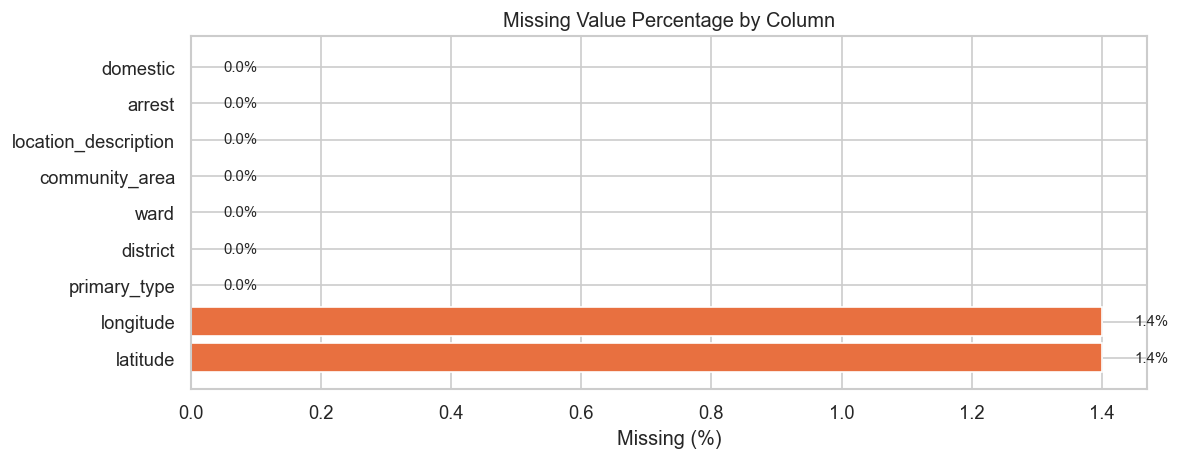

In [7]:
cols_to_check = ['primary_type', 'district', 'ward', 'community_area',
                 'latitude', 'longitude', 'location_description', 'arrest', 'domestic']

null_counts = []
for c in cols_to_check:
    n = df.filter(isnull(col(c)) | isnan(col(c)) if c in ['latitude','longitude'] else isnull(col(c))).count()
    null_counts.append({'column': c, 'null_count': n, 'null_pct': round(n / total_rows * 100, 2)})

null_df = pd.DataFrame(null_counts).sort_values('null_pct', ascending=False)
print(null_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(null_df['column'], null_df['null_pct'], color='#E87040')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Value Percentage by Column')
for bar, val in zip(bars, null_df['null_pct']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURES}/missing_values.png')
plt.show()

## 5. Top 10 Crime Types
Rubric: *Kategorik degiskenlerin dagilim analizi*

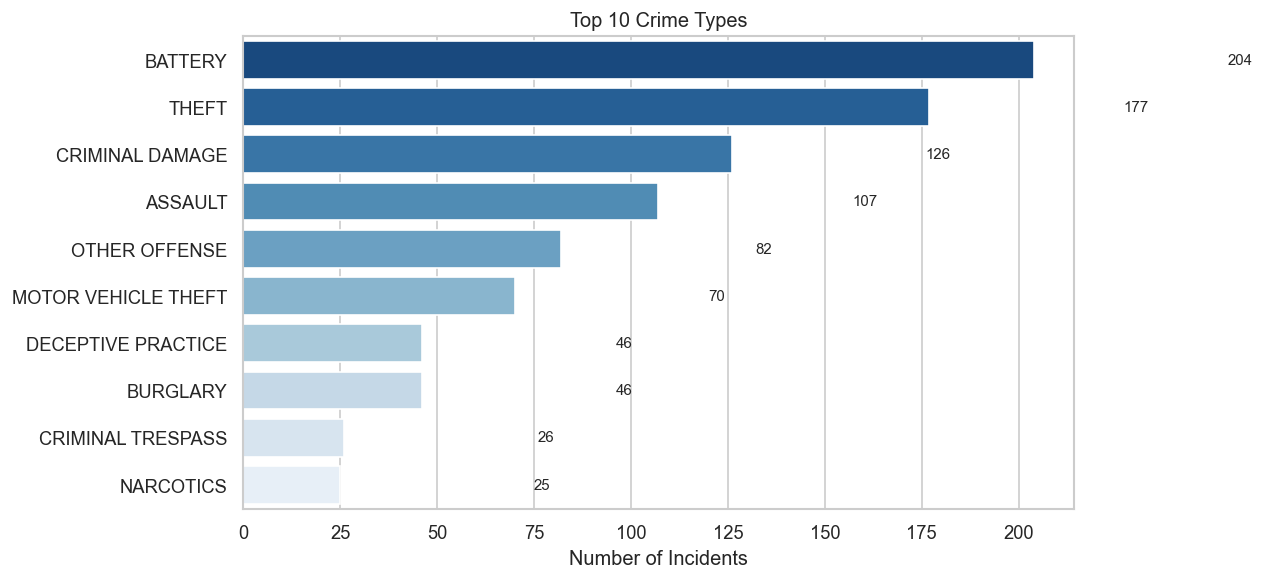

In [8]:
top10 = df.groupBy('primary_type').count() \
          .orderBy(desc('count')) \
          .limit(10) \
          .toPandas()

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=top10, y='primary_type', x='count', palette='Blues_r', ax=ax)
ax.set_title('Top 10 Crime Types')
ax.set_xlabel('Number of Incidents')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, (_, row) in enumerate(top10.iterrows()):
    ax.text(row['count'] + 50, i, f"{row['count']:,}", va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURES}/top10_crime_types.png')
plt.show()

## 6. Yearly trend

Rubric: *zaman serisi — yıllık özet; günlük ve saatlik trendler aşağıda (§7–8).*


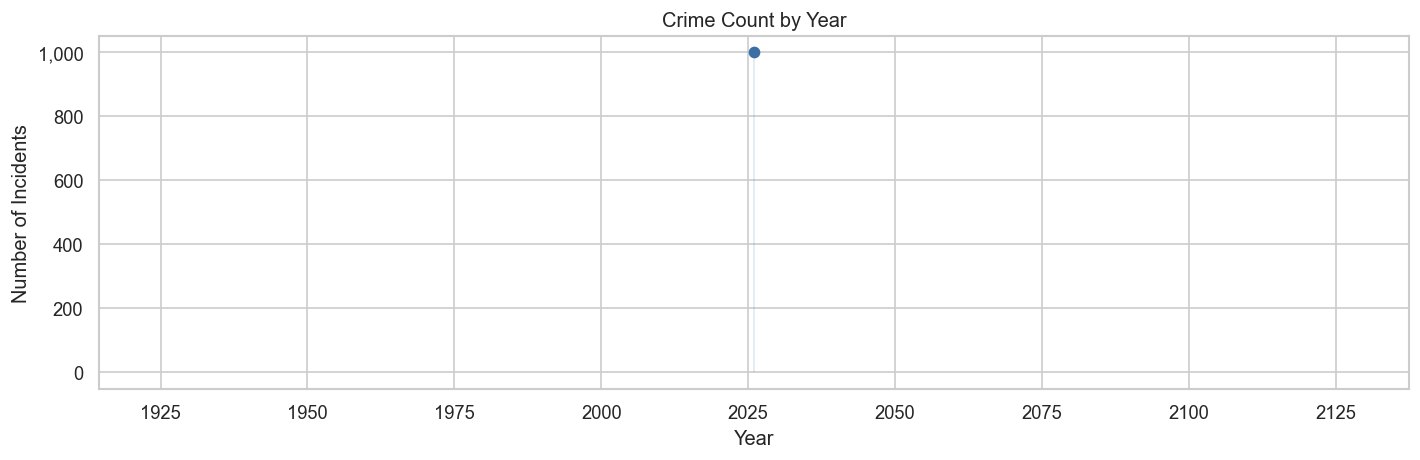

In [9]:
yearly = df.withColumn('year', year(col('date_ts'))) \
           .groupBy('year').count() \
           .orderBy('year') \
           .toPandas()
yearly = yearly.dropna(subset=['year'])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(yearly['year'], yearly['count'], marker='o', linewidth=2, color='#3A6EA5')
ax.fill_between(yearly['year'], yearly['count'], alpha=0.15, color='#3A6EA5')
ax.set_title('Crime Count by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Incidents')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(f'{FIGURES}/yearly_trend.png')
plt.show()

## 7. Daily incident trend

Rubric: *günlük zaman serisi — her takvim günü için olay sayısı (dalgalanma, sezonluk, ani günler görülebilir).*


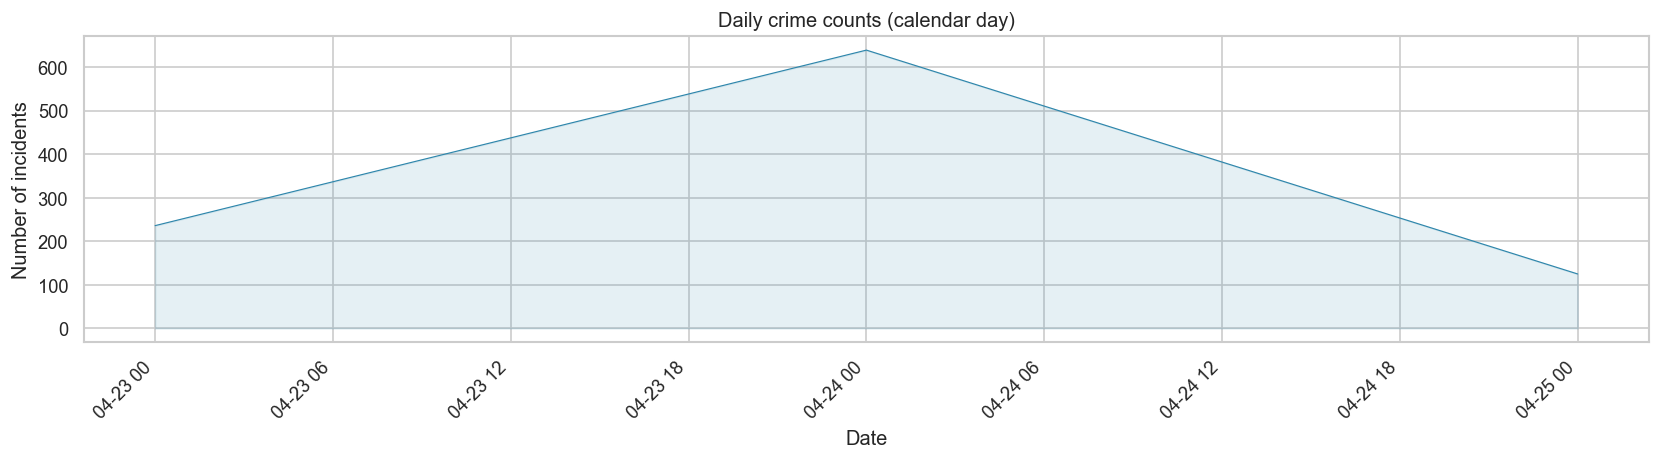

Busiest day in sample: 2026-04-24 (639 incidents)
Quietest day in sample: 2026-04-25 (125 incidents)
Mean crimes/day (non-null dates): 333.3


In [10]:
daily = (
    df.withColumn('day', to_date(col('date_ts')))
    .filter(col('day').isNotNull())
    .groupBy('day')
    .agg(count('*').alias('count'))
    .orderBy('day')
    .toPandas()
)
daily['day'] = pd.to_datetime(daily['day'])

if daily.empty:
    print('No dated rows found — skipping daily trend chart.')
else:
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(daily['day'], daily['count'], linewidth=0.7, color='#2E86AB')
    ax.fill_between(daily['day'], daily['count'], alpha=0.12, color='#2E86AB')
    ax.set_title('Daily crime counts (calendar day)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Number of incidents')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/daily_trend.png')
    plt.show()

    peak_day = daily.sort_values('count', ascending=False).iloc[0]
    quiet_day = daily.sort_values('count').iloc[0]
    print(f"Busiest day in sample: {peak_day['day'].date()} ({int(peak_day['count']):,} incidents)")
    print(f"Quietest day in sample: {quiet_day['day'].date()} ({int(quiet_day['count']):,} incidents)")
    print(f"Mean crimes/day (non-null dates): {daily['count'].mean():.1f}")

## 8. Hourly Distribution

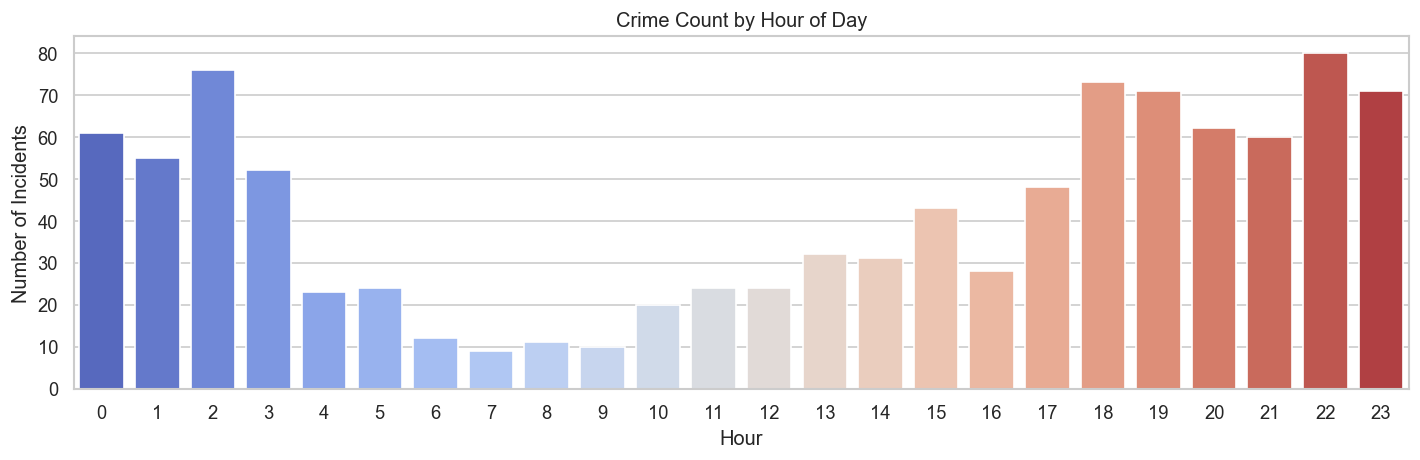

In [11]:
hourly = df.withColumn('hour', hour(col('date_ts'))) \
           .groupBy('hour').count() \
           .orderBy('hour') \
           .toPandas()
hourly = hourly.dropna(subset=['hour'])

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=hourly, x='hour', y='count', palette='coolwarm', ax=ax)
ax.set_title('Crime Count by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Number of Incidents')
plt.tight_layout()
plt.savefig(f'{FIGURES}/hourly_distribution.png')
plt.show()

## 9. District Distribution
Rubric: *olay dagilimi — district bazli*

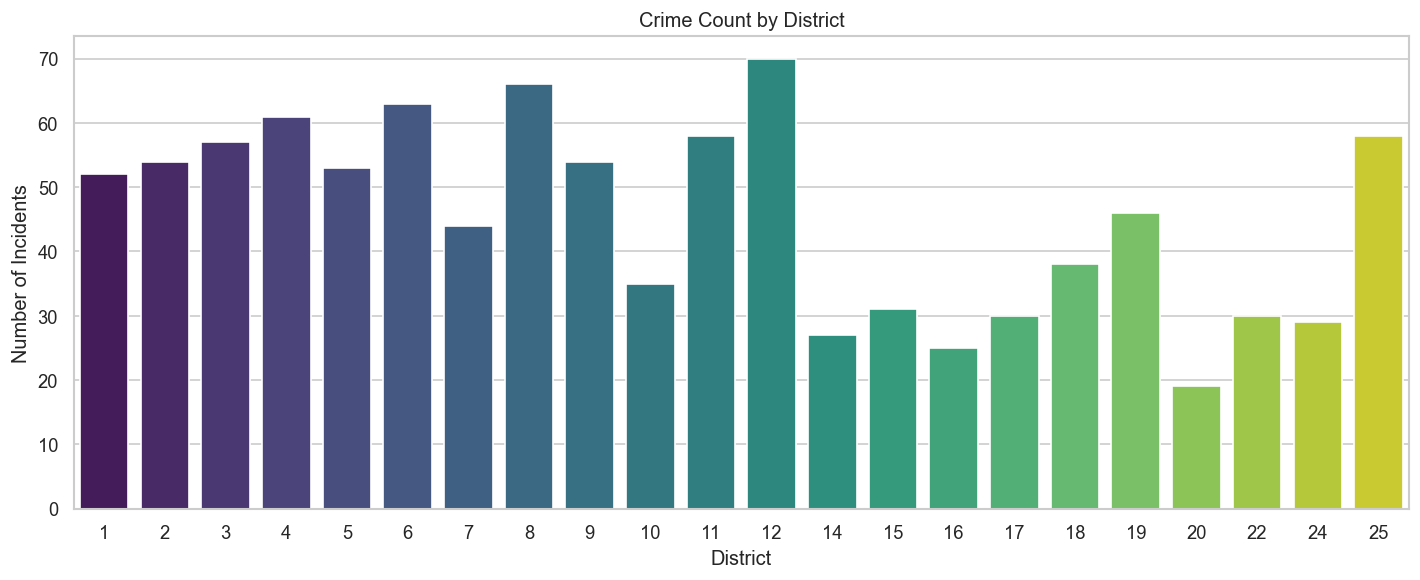

In [12]:
district = df.groupBy('district').count() \
             .orderBy(desc('count')) \
             .toPandas()
district = district.dropna(subset=['district'])

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=district, x='district', y='count', palette='viridis', ax=ax)
ax.set_title('Crime Count by District')
ax.set_xlabel('District')
ax.set_ylabel('Number of Incidents')
plt.tight_layout()
plt.savefig(f'{FIGURES}/district_heatmap.png')
plt.show()

## 10. Day of Week vs Hour Heatmap

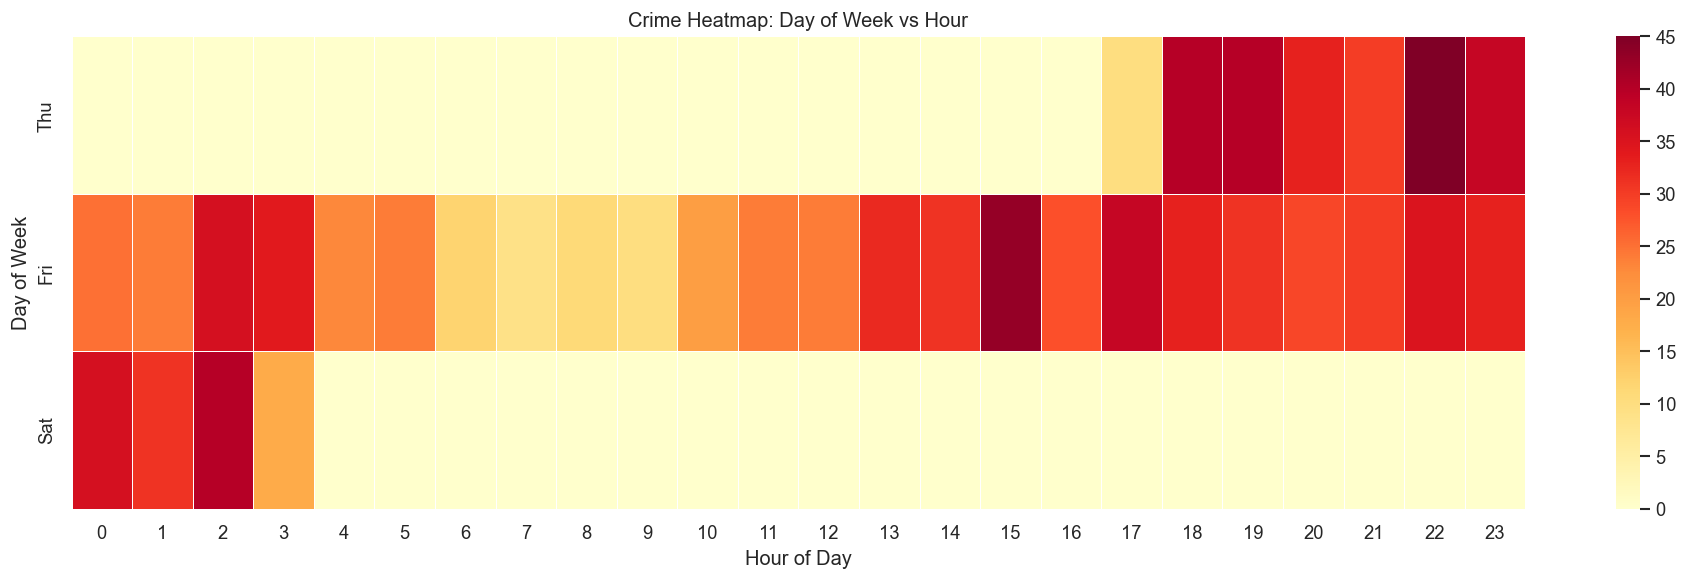

In [13]:
dow_hour = df.withColumn('hour', hour(col('date_ts'))) \
             .withColumn('dow', dayofweek(col('date_ts'))) \
             .groupBy('dow', 'hour').count() \
             .toPandas()
dow_hour = dow_hour.dropna()

if dow_hour.empty:
    print('No dated rows found — skipping heatmap.')
else:
    pivot = dow_hour.pivot(index='dow', columns='hour', values='count').fillna(0)
    day_labels = {1:'Sun', 2:'Mon', 3:'Tue', 4:'Wed', 5:'Thu', 6:'Fri', 7:'Sat'}
    pivot.index = [day_labels.get(i, i) for i in pivot.index]

    fig, ax = plt.subplots(figsize=(16, 5))
    sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, ax=ax)
    ax.set_title('Crime Heatmap: Day of Week vs Hour')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Day of Week')
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/weekday_hour_heatmap.png')
    plt.show()

## 11. Domestic vs Arrest Comparison

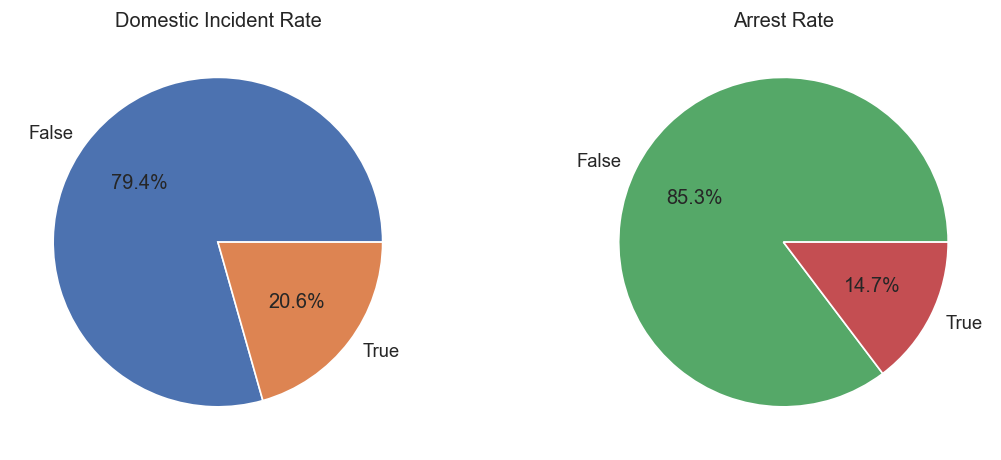

In [14]:
domestic_counts = df.groupBy('domestic').count().toPandas()
arrest_counts   = df.groupBy('arrest').count().toPandas()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].pie(
    domestic_counts['count'],
    labels=domestic_counts['domestic'],
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452']
)
axes[0].set_title('Domestic Incident Rate')

axes[1].pie(
    arrest_counts['count'],
    labels=arrest_counts['arrest'],
    autopct='%1.1f%%',
    colors=['#55A868', '#C44E52']
)
axes[1].set_title('Arrest Rate')

plt.tight_layout()
plt.savefig(f'{FIGURES}/domestic_arrest_comparison.png')
plt.show()

## 12. Location Description Distribution

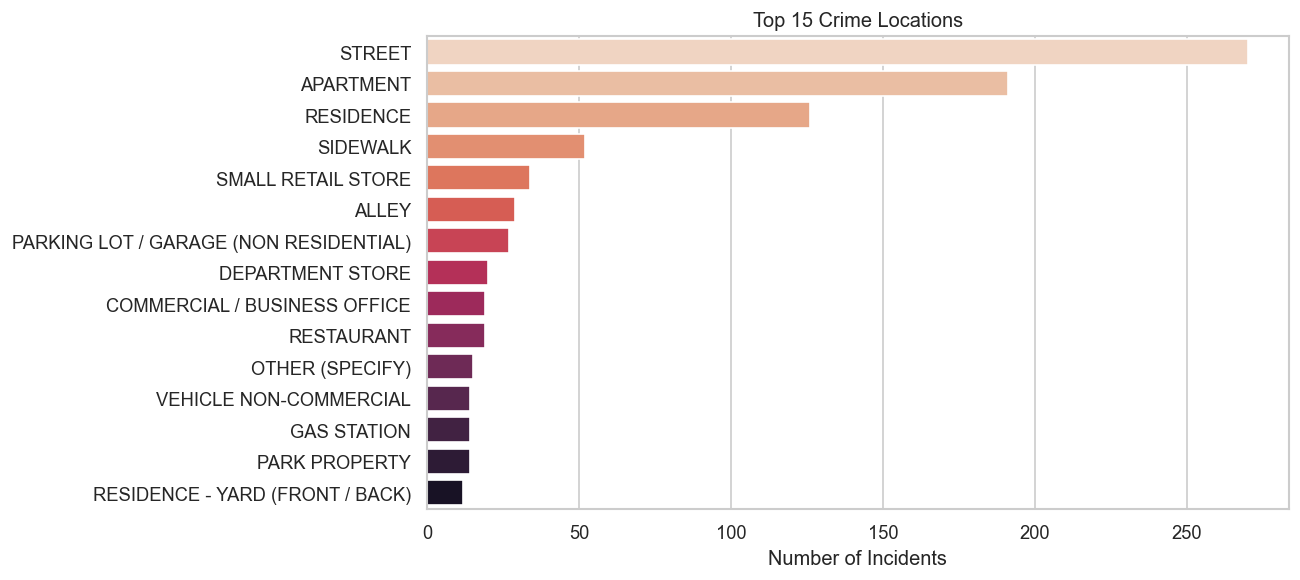

In [15]:
location = df.groupBy('location_description').count() \
             .orderBy(desc('count')) \
             .limit(15) \
             .toPandas()

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=location, y='location_description', x='count', palette='rocket_r', ax=ax)
ax.set_title('Top 15 Crime Locations')
ax.set_xlabel('Number of Incidents')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(f'{FIGURES}/location_description_distribution.png')
plt.show()

## 13. Numerical variable distributions

Rubric: *sayısal değişkenlerin dağılım analizi* — coğrafi koordinatlar (`latitude`, `longitude`) ve polis alanı sayıları (`beat`, `ward`, `community_area`). Özet istatistikler Spark `summary` ile; yoğunluk için örnekleme + histogram.


Spark summary (numeric columns):
+-------+------------------+--------------------+-----------------+-----------------+-----------------+
|summary|latitude          |longitude           |beat             |ward             |community_area   |
+-------+------------------+--------------------+-----------------+-----------------+-----------------+
|count  |986               |986                 |1000             |1000             |1000             |
|mean   |41.83879899954979 |-87.66616982932656  |1109.075         |21.942           |38.014           |
|stddev |0.0870266076227788|0.058528044357302716|707.8702689707299|13.70870397100195|21.10543160523478|
|min    |41.649066001      |-87.905227221       |111              |1                |1                |
|25%    |41.764682081      |-87.709009069       |523              |9                |24               |
|50%    |41.853825703      |-87.659660787       |934              |21               |34               |
|75%    |41.902058046      |-87

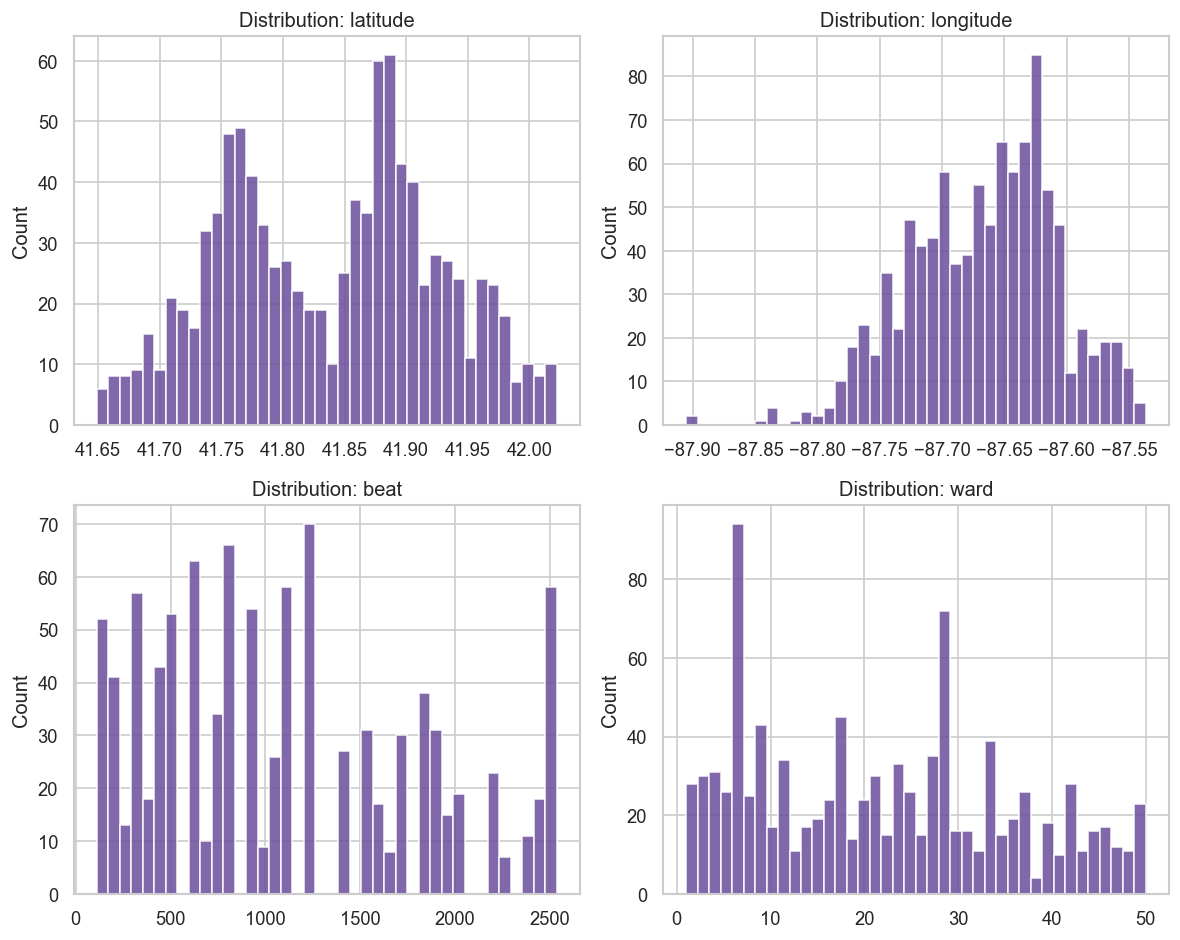

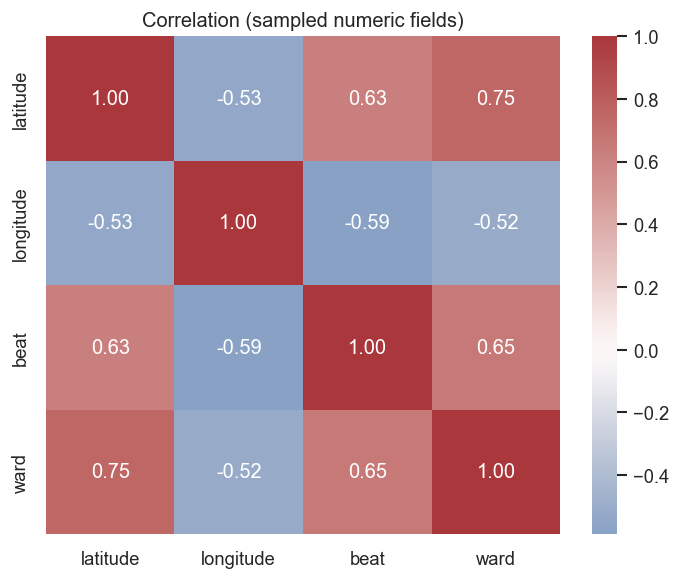

In [16]:
numeric_cols = ['latitude', 'longitude', 'beat', 'ward', 'community_area']
existing = [c for c in numeric_cols if c in df.columns]
print('Spark summary (numeric columns):')
df.select(*[col(x) for x in existing]).summary().show(truncate=False)

plot_cols = [c for c in ['latitude', 'longitude', 'beat', 'ward'] if c in df.columns]
if not plot_cols:
    print('No numeric columns available for histograms.')
else:
    sample_n = min(50_000, total_rows)
    frac = sample_n / total_rows if total_rows else 1.0
    sdf = df.select(*plot_cols).sample(withReplacement=False, fraction=min(1.0, frac), seed=42)
    pdf = sdf.toPandas()

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.ravel()
    for ax, name in zip(axes, plot_cols):
        s = pdf[name].dropna()
        ax.hist(s, bins=40, color='#6B4E9B', edgecolor='white', alpha=0.85)
        ax.set_title(f'Distribution: {name}')
        ax.set_ylabel('Count')
    for j in range(len(plot_cols), 4):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/numeric_distributions.png')
    plt.show()

    if len(plot_cols) >= 2:
        corr = pdf[plot_cols].corr(numeric_only=True)
        fig2, ax2 = plt.subplots(figsize=(6, 5))
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax2)
        ax2.set_title('Correlation (sampled numeric fields)')
        plt.tight_layout()
        plt.savefig(f'{FIGURES}/numeric_correlation_heatmap.png')
        plt.show()


### Keşifler (ek EDA)

- **Zaman:** Günlük seri, tekil olay günleri ve olası tatil/dönem etkilerini görünür kılar; saatlik ve hafta×saat ısı haritası ile birlikte tam *günlük/saatlik* resim oluşur.
- **Sayısal:** Enlem/boylam histogramları Chicago içi yoğunluğu; beat/ward polis idari yapısını yansıtır; korelasyon ısı haritası çoklu doğrusal ilişki ipuçları verir (nedensellik değildir).
- **Delta:** `delta_silver` → **`dashboard/figures/from-delta-lake/silver/`**; `delta_gold` → **`.../gold/`**. CSV → **`from-csv/`**.


## 14. Summary

Findings in the next cell are **computed from this run** of the notebook (same sample as the charts above).

In [17]:
from IPython.display import display, Markdown

t = total_rows
row = df.groupBy('primary_type').count().orderBy(desc('count')).first()
most_common_crime = row['primary_type']
most_common_crime_n = row['count']
crime_share = round(100.0 * most_common_crime_n / t, 1) if t else 0.0

hdf = (
    df.withColumn('hour', hour(col('date_ts')))
    .filter(col('hour').isNotNull())
    .groupBy('hour')
    .count()
    .orderBy(desc('count'))
)
peak_rows = hdf.limit(2).collect()
peak_hours_str = (
    ', '.join(f"{int(r['hour']):02d}:00" for r in peak_rows)
    if peak_rows
    else 'n/a'
)

day_agg = (
    df.withColumn('day', to_date(col('date_ts')))
    .filter(col('day').isNotNull())
    .groupBy('day')
    .count()
)
busiest_d = day_agg.orderBy(desc('count')).first()
quiet_d   = day_agg.orderBy(col('count').asc()).first()

dist_top = (
    df.filter(col('district').isNotNull())
    .groupBy('district')
    .count()
    .orderBy(desc('count'))
    .limit(3)
    .collect()
)
districts_str = ', '.join(str(int(r['district'])) for r in dist_top)

a_true = df.filter((col('arrest') == True) | (col('arrest') == 'true')).count()
arrest_pct = round(100.0 * a_true / t, 1) if t else 0.0

d_true = df.filter((col('domestic') == True) | (col('domestic') == 'true')).count()
domestic_pct = round(100.0 * d_true / t, 1) if t else 0.0

loc = (
    df.filter(col('location_description').isNotNull())
    .groupBy('location_description')
    .count()
    .orderBy(desc('count'))
    .first()
)
top_location   = loc['location_description'] if loc else 'n/a'
top_location_n = loc['count'] if loc else 0

from pyspark.sql import functions as F

yr = (
    df.select(F.year(col('date_ts')).alias('yy'))
    .filter(col('yy').isNotNull())
    .agg(F.min(col('yy')).alias('ymin'), F.max(col('yy')).alias('ymax'))
    .collect()[0]
)
ymin, ymax = yr['ymin'], yr['ymax']

lines = [
    '| Finding | Detail |',
    '|---------|--------|',
    f'| **Record count** | {t:,} rows |',
]
if ymin is not None and ymax is not None:
    lines.append(f'| **Years in sample** | {int(ymin)}–{int(ymax)} |')

if busiest_d is not None:
    lines.append(f'| **Busiest calendar day** | {busiest_d["day"]} ({busiest_d["count"]:,} incidents) |')
else:
    lines.append('| **Busiest calendar day** | n/a (no dated rows) |')

if quiet_d is not None:
    lines.append(f'| **Quietest calendar day** | {quiet_d["day"]} ({quiet_d["count"]:,} incidents) |')
else:
    lines.append('| **Quietest calendar day** | n/a (no dated rows) |')

lines.extend([
    f'| **Most common crime** | {most_common_crime} ({most_common_crime_n:,} incidents, {crime_share}% of rows) |',
    f'| **Peak hours (top 2 by volume)** | {peak_hours_str} |',
    f'| **Highest-crime districts (top 3)** | {districts_str} |',
    f'| **Arrest rate** | {arrest_pct}% ({a_true:,} incidents) |',
    f'| **Domestic flag** | {domestic_pct}% ({d_true:,} incidents) |',
    f'| **Most common location** | {top_location} ({top_location_n:,} incidents) |',
])
ndf = globals().get('null_df')
if ndf is not None and len(ndf) > 0:
    w = ndf.iloc[0]
    lines.append(
        f"| **Largest missingness** | `{w['column']}` — {w['null_pct']}% null |"
    )
lines.extend(['', f'Figures: `daily_trend`, `numeric_distributions`, and others under `{FIGURES}`.'])
display(Markdown('\n'.join(lines)))

| Finding | Detail |
|---------|--------|
| **Record count** | 1,000 rows |
| **Years in sample** | 2026–2026 |
| **Busiest calendar day** | 2026-04-24 (639 incidents) |
| **Quietest calendar day** | 2026-04-25 (125 incidents) |
| **Most common crime** | BATTERY (204 incidents, 20.4% of rows) |
| **Peak hours (top 2 by volume)** | 22:00, 02:00 |
| **Highest-crime districts (top 3)** | 12, 8, 6 |
| **Arrest rate** | 14.7% (147 incidents) |
| **Domestic flag** | 20.6% (206 incidents) |
| **Most common location** | STREET (270 incidents) |
| **Largest missingness** | `latitude` — 1.4% null |

Figures: `daily_trend`, `numeric_distributions`, and others under `/Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/from-delta-lake/silver`.

In [18]:
spark.stop()
print(f'EDA complete. Figures saved under {FIGURES}')

EDA complete. Figures saved under /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/from-delta-lake/silver
